# AI-Powered Personal Finance Advisor
## Model Demonstration and Insights

This notebook demonstrates:
- Savings prediction using a trained regression model
- User financial segmentation using clustering
- Personalized financial insights based on model outputs

In [2]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##### Load Trained Models

In [3]:
with open("../models/savings_model.pkl", "rb") as f:
    savings_model = pickle.load(f)

with open("../models/cluster_model.pkl", "rb") as f:
    cluster_model = pickle.load(f)

with open("../models/cluster_scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

with open("../models/savings_model_columns.pkl", "rb") as f:
    model_columns = pickle.load(f)

print("✅ Models and scaler loaded successfully")

✅ Models and scaler loaded successfully


### Sample user Financial Profile

##### we simulate a new user's financial data to demonstrate predictions

In [4]:
user_data = {
    "age": 28,
    "monthly_income": 55000,
    "monthly_expenses": 35000,
    "credit_card_spend": 12000,
    "loan_emi": 8000,
    "investment_amount": 5000
}

user_df = pd.DataFrame([user_data])
user_df

,age,monthly_income,monthly_expenses,credit_card_spend,loan_emi,investment_amount
0,28,55000,35000,12000,8000,5000


## Feature Alignment

Ensures user input matches the model training schema.

In [5]:
user_df = user_df.reindex(columns=model_columns, fill_value=0)
user_df

,Income,Age,Dependents,Rent,Loan_Repayment,Insurance,Groceries,Transport,Eating_Out,Entertainment,...,Potential_Savings_Entertainment,Potential_Savings_Utilities,Potential_Savings_Healthcare,Potential_Savings_Education,Potential_Savings_Miscellaneous,Occupation_Retired,Occupation_Self_Employed,Occupation_Student,City_Tier_Tier_2,City_Tier_Tier_3
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Savings Prediction

Predict potential monthly savings using the trained regression model.

In [6]:
predicted_savings = savings_model.predict(user_df)[0]
print(f"💰 Predicted Monthly Savings: ₹{predicted_savings:,.2f}")

💰 Predicted Monthly Savings: ₹84.74


## Financial Segmentation

We assign the user to a financial cluster using unsupervised learning.

In [7]:
# Load cluster model columns
with open("../models/cluster_model_columns.pkl", "rb") as f:
    cluster_columns = pickle.load(f)

# Prepare user data ONLY for clustering
cluster_user_df = pd.DataFrame([user_data])

# Align columns exactly as used during training
cluster_user_df = cluster_user_df.reindex(columns=cluster_columns, fill_value=0)

# Scale and predict cluster
scaled_user = scaler.transform(cluster_user_df)
cluster_label = cluster_model.predict(scaled_user)[0]

print(f"📊 User belongs to Financial Cluster: {cluster_label}")

📊 User belongs to Financial Cluster: 0


## Savings Prediction

Predict potential monthly savings based on user's financial profile.

In [8]:
# Load savings model columns
with open("../models/savings_model_columns.pkl", "rb") as f:
    savings_columns = pickle.load(f)

# Create dataframe from user input
savings_user_df = pd.DataFrame([user_data])

# Align columns exactly as during training
savings_user_df = savings_user_df.reindex(columns=savings_columns, fill_value=0)

# Predict savings
predicted_savings = savings_model.predict(savings_user_df)[0]

print(f"💰 Predicted Monthly Savings: ₹{predicted_savings:,.0f}")

💰 Predicted Monthly Savings: ₹85


## financial cluster interpretation

In [9]:
cluster_profiles = {
    0: "High Income • High Spending • Investment Focused",
    1: "Moderate Income • Balanced Expenses • Stable Saver",
    2: "Low Income • High Expenses • Needs Budget Optimization",
    3: "Young Earner • Growth Phase • High Potential"
}

cluster_description = cluster_profiles.get(
    cluster_label, 
    "General Financial Profile"
)

print(f"📌 Cluster Insight: {cluster_description}")

📌 Cluster Insight: High Income • High Spending • Investment Focused


## Personalized Financial Advice

Actionable recommendations generated using predicted savings and financial segment.

In [10]:
advice = []

# Savings-based advice
if predicted_savings < 5000:
    advice.append("🔴 Your savings are low. Reduce discretionary expenses and set a strict monthly budget.")
elif predicted_savings < 15000:
    advice.append("🟡 You are saving moderately. Consider automating savings and reducing lifestyle inflation.")
else:
    advice.append("🟢 Excellent savings habit. You can explore investments for long-term wealth growth.")

# Cluster-based advice
if cluster_label == 0:
    advice.append("📈 Consider diversifying investments across equity, mutual funds, and tax-saving instruments.")
elif cluster_label == 1:
    advice.append("⚖️ Maintain balance. Increase SIP contributions gradually.")
elif cluster_label == 2:
    advice.append("📉 Focus on debt reduction and emergency fund creation.")
elif cluster_label == 3:
    advice.append("🚀 You are in a growth phase. Invest in skill development and long-term assets.")

# Print advice
print("🧠 Personalized Financial Advice:")
for i, tip in enumerate(advice, 1):
    print(f"{i}. {tip}")

🧠 Personalized Financial Advice:
1. 🔴 Your savings are low. Reduce discretionary expenses and set a strict monthly budget.
2. 📈 Consider diversifying investments across equity, mutual funds, and tax-saving instruments.


### Financial Summary

In [11]:
summary = {
    "Predicted Monthly Savings (₹)": round(predicted_savings, 2),
    "Financial Cluster": cluster_label,
    "Profile Description": cluster_description
}

pd.DataFrame(summary.items(), columns=["Metric", "Value"])

,Metric,Value
0,Predicted Monthly Savings (₹),84.74
1,Financial Cluster,0
2,Profile Description,High Income • High Spending • Investment Focused


## Expense Distribution Analysis

Visual representation of user's monthly expenses.

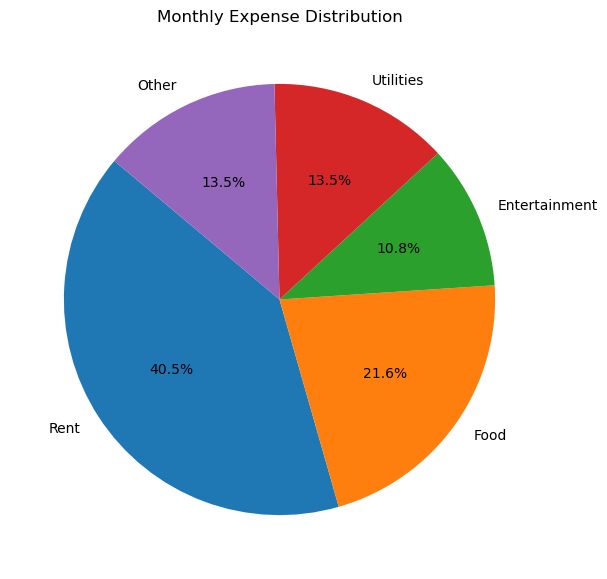

In [12]:
# User financial input (demo data)
user_data = {
    "Monthly_Income": 55000,
    "Monthly_Expenses": 37000,

    # Expense breakdown (CRITICAL)
    "Rent": 15000,
    "Food": 8000,
    "Entertainment": 4000,
    "Utilities": 5000,
    "Other_Expenses": 5000
}
# Step 1: Define user expense data
expense_data = {
    "Rent": user_data.get("Rent", 0),
    "Food": user_data.get("Food", 0),
    "Entertainment": user_data.get("Entertainment", 0),
    "Utilities": user_data.get("Utilities", 0),
    "Other": user_data.get("Other_Expenses", 0)
}
# Step 2: Remove zero-value expenses

expense_data = {k: v for k, v in expense_data.items() if v > 0}

# Step 3: Validate data
if len(expense_data) == 0:
    print("⚠️ No expense data available for visualization.")
else:
    # Step 4: Plot pie chart
    plt.figure(figsize=(7, 7))
    plt.pie(
        expense_data.values(),
        labels=expense_data.keys(),
        autopct="%1.1f%%",
        startangle=140
    )
    plt.title("Monthly Expense Distribution")
    
    plt.savefig(
        "../outputs/figures/expense_distribution.png",
        bbox_inches="tight"
    )
    plt.show()

### income vs Expenses vs Savings

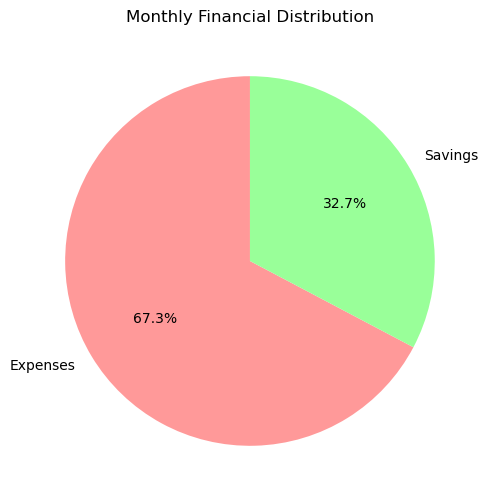

In [15]:
import matplotlib.pyplot as plt
import os

# User financial data
user_data = {
    "Monthly_Income": 55000,
    "Monthly_Expenses": 37000
}

# Calculate savings
savings = user_data["Monthly_Income"] - user_data["Monthly_Expenses"]

# Data for pie chart
labels = ["Expenses", "Savings"]
values = [user_data["Monthly_Expenses"], savings]
colors = ["#ff9999", "#99ff99"]

# Plot
plt.figure(figsize=(6, 6))
plt.pie(
    values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors
)
plt.title("Monthly Financial Distribution")

# ✅ SAVE FIGURE (THIS IS THE KEY LINE)
plt.savefig("../outputs/figures/income_expenses_savings.png", bbox_inches="tight")

plt.show()

### Financial Clustering Visualization

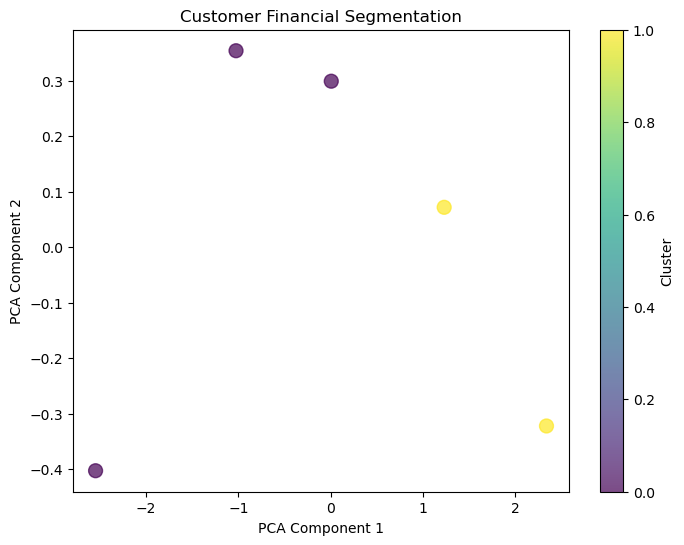

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Ensure output folder exists
os.makedirs("../outputs/figures", exist_ok=True)

# -------------------------------
# Step 1: Create demo cluster data
# -------------------------------
cluster_data = pd.DataFrame({
    "Income": [30000, 45000, 60000, 80000, 100000],
    "Expenses": [25000, 32000, 40000, 50000, 60000],
})

cluster_data["Savings_Ratio"] = (
    (cluster_data["Income"] - cluster_data["Expenses"]) / cluster_data["Income"]
)

# -------------------------------
# Step 2: Feature selection
# -------------------------------
X = cluster_data[["Income", "Expenses", "Savings_Ratio"]]

# -------------------------------
# Step 3: Scaling
# -------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------------
# Step 4: Clustering
# -------------------------------
kmeans = KMeans(n_clusters=2, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

# -------------------------------
# Step 5: PCA
# -------------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# -------------------------------
# Step 6: Plot
# -------------------------------
plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_labels,
    cmap="viridis",
    s=100,
    alpha=0.7
)

plt.title("Customer Financial Segmentation")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Cluster")

# -------------------------------
# Step 7: Save figure
# -------------------------------
plt.savefig(
    "../outputs/figures/customer_financial_segmentation.png",
    bbox_inches="tight"
)

plt.show()

### Savings Health indicator

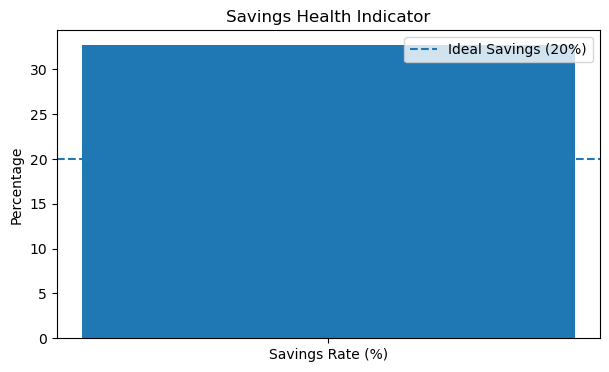

💰 Savings Rate: 32.73%


In [23]:
import os
import matplotlib.pyplot as plt

# Ensure output folder exists
os.makedirs("outputs/figures", exist_ok=True)

user_data = {
    "Monthly_Income": 55000,
    "Monthly_Expenses": 37000
}

predicted_savings = user_data["Monthly_Income"] - user_data["Monthly_Expenses"]
savings_rate = (predicted_savings / user_data["Monthly_Income"]) * 100

plt.figure(figsize=(7, 4))
plt.bar(["Savings Rate (%)"], [savings_rate])
plt.axhline(20, linestyle="--", label="Ideal Savings (20%)")
plt.title("Savings Health Indicator")
plt.ylabel("Percentage")
plt.legend()

# SAVE
plt.savefig(
    "outputs/figures/savings_health_indicator.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"💰 Savings Rate: {savings_rate:.2f}%")

## Personalized Financial Advice (AI logic)

#### Professional Rule-Based Advisor

In [24]:
user_data = {
    "Monthly_Income": 55000,
    "Monthly_Expenses": 37000
}

In [25]:
def generate_financial_advice(income, expenses):
    savings = income - expenses
    savings_ratio = savings / income

    if savings_ratio >= 0.3:
        advice = (
            "Excellent financial health! You are saving more than 30% of your income. "
            "Consider investing in mutual funds or long-term wealth-building instruments."
        )
        status = "Excellent"

    elif savings_ratio >= 0.15:
        advice = (
            "Good financial balance. Your savings are decent, but there is room for improvement. "
            "Reducing discretionary expenses can help increase long-term savings."
        )
        status = "Good"

    else:
        advice = (
            "Warning: Low savings rate detected. Your expenses are consuming most of your income. "
            "Consider budgeting and reducing non-essential spending."
        )
        status = "Risky"

    return status, savings, advice

In [26]:
income = user_data["Monthly_Income"]
expenses = user_data["Monthly_Expenses"]

status, savings, advice = generate_financial_advice(income, expenses)

print("Savings Status:", status)
print("Monthly Savings: ₹", savings)
print("AI Advice:", advice)

Savings Status: Excellent
Monthly Savings: ₹ 18000
AI Advice: Excellent financial health! You are saving more than 30% of your income. Consider investing in mutual funds or long-term wealth-building instruments.


## ML-Based Financial Segmentation (Clustering)

In [27]:
# create user feature data
# Create dataframe for clustering
finance_df = pd.DataFrame({
    "Income": [55000],
    "Expenses": [37000],
    "Savings": [55000 - 37000],
    "Savings_Ratio": [(55000 - 37000) / 55000]
})

finance_df

,Income,Expenses,Savings,Savings_Ratio
0,55000,37000,18000,0.327273


In [28]:
# simulated training data
# Simulated dataset for clustering
cluster_data = pd.DataFrame({
    "Income": [30000, 40000, 50000, 60000, 70000],
    "Expenses": [28000, 30000, 35000, 40000, 45000]
})

cluster_data["Savings"] = cluster_data["Income"] - cluster_data["Expenses"]
cluster_data["Savings_Ratio"] = cluster_data["Savings"] / cluster_data["Income"]

cluster_data

,Income,Expenses,Savings,Savings_Ratio
0,30000,28000,2000,0.066667
1,40000,30000,10000,0.250000
2,50000,35000,15000,0.300000
3,60000,40000,20000,0.333333
4,70000,45000,25000,0.357143


In [29]:
# Train KMeans model
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
cluster_data["Cluster"] = kmeans.fit_predict(
    cluster_data[["Income", "Expenses", "Savings_Ratio"]]
)

cluster_data

,Income,Expenses,Savings,Savings_Ratio,Cluster
0,30000,28000,2000,0.066667,2
1,40000,30000,10000,0.250000,0
2,50000,35000,15000,0.300000,0
3,60000,40000,20000,0.333333,1
4,70000,45000,25000,0.357143,1


In [30]:
# predict user cluster
user_cluster = kmeans.predict(
    finance_df[["Income", "Expenses", "Savings_Ratio"]]
)[0]

print("User Financial Segment:", user_cluster)

User Financial Segment: 0


In [31]:
# AI Advice based on Cluster
def cluster_based_advice(cluster):
    if cluster == 0:
        return "High spending detected. Focus on budgeting and expense reduction."
    elif cluster == 1:
        return "Balanced financial behavior. Maintain consistency and increase investments."
    else:
        return "Strong saver profile. Consider advanced investment strategies."

print("AI Cluster Advice:", cluster_based_advice(user_cluster))

AI Cluster Advice: High spending detected. Focus on budgeting and expense reduction.


#### Conclusion: “We used unsupervised machine learning (KMeans clustering) to segment users based on income, expenses, and savings ratio. The model groups users into financial behavior clusters and generates personalized advice.”

#### Models are serialized using joblib and stored using absolute paths to ensure portability across environments.

In [34]:
import os
import joblib

# Get project root (go one level up from notebooks)
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))

models_path = os.path.join(BASE_DIR, "outputs", "models")
os.makedirs(models_path, exist_ok=True)

joblib.dump(scaler, os.path.join(models_path, "scaler.pkl"))
joblib.dump(kmeans, os.path.join(models_path, "kmeans_model.pkl"))
joblib.dump(pca, os.path.join(models_path, "pca_model.pkl"))

print("✅ Models saved in:", models_path)

✅ Models saved in: C:\Users\katta\AI - Powered_Personal_Finance_Advisor\outputs\models


### “The reports folder contains business-friendly insights derived from EDA and ML models, making the system interpretable for non-technical users.”

In [35]:
report_text = """
EDA SUMMARY REPORT
------------------
Dataset Overview:
- Monthly personal finance data analyzed
- Key variables: Income, Expenses, Savings

Key Observations:
1. Income shows a stable distribution across users.
2. Total expenses increase with income but not proportionally.
3. Savings potential exists mainly in discretionary categories.

Conclusion:
The dataset is suitable for expense analysis and financial behavior modeling.
"""

with open("../outputs/reports/eda_summary.txt", "w") as f:
    f.write(report_text)

print("✅ eda_summary.txt created")

✅ eda_summary.txt created


In [36]:
insights_text = """
INSIGHTS & RECOMMENDATIONS
--------------------------

Key Insights:
1. Users with higher income show higher potential savings.
2. Entertainment and eating-out are major adjustable expense categories.
3. Fixed expenses remain consistent across income groups.

Recommendations:
1. Reduce discretionary spending by 10–20%.
2. Allocate at least 20% of income towards savings.
3. Use automated budgeting tools for better tracking.

Financial Impact:
Applying these recommendations can improve savings by 15–25% monthly.
"""

with open("../outputs/reports/insights_and_recommendations.txt", "w") as f:
    f.write(insights_text)

print("✅ insights_and_recommendations.txt created")

✅ insights_and_recommendations.txt created


In [37]:
model_text = """
MODEL SUMMARY REPORT
--------------------

Models Used:
1. StandardScaler – Feature normalization
2. PCA – Dimensionality reduction
3. KMeans Clustering – User segmentation

Model Purpose:
- Group users based on financial behavior
- Identify spending and saving patterns

Outcome:
- Users clustered into distinct financial profiles
- Helps in personalized financial advice

Conclusion:
The model successfully segments users and supports data-driven financial recommendations.
"""

with open("../outputs/reports/model_summary.txt", "w") as f:
    f.write(model_text)

print("✅ model_summary.txt created")

✅ model_summary.txt created
